# AML Pseudobulk Training Progress 

**Loss = MSE** — this diffusion model uses pure MSE loss.

**MMD splits:**
- `train` — samples seen during training
- `validation` — held-out *test* samples never seen during training

## Sections

1. **Run summary** — headline metrics and checkpoint recommendation
2. **Generalization quality (MMD)** — main signal for model quality
    - Periodic MMD: train vs held-out test
    - Per-sample MMD trajectories
3. **Optimization diagnostics** — loss & gradient behaviour
    - Core metrics: loss, gradient norm, parameter norm
    - Tail zoom: last 20% of training
    - Loss by timestep quartile

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

#plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')

project_root = Path.cwd()
if not (project_root / 'output').exists() and (project_root.parent / 'output').exists():
    project_root = project_root.parent


In [ ]:
# Main configuration.
log_dir = project_root / 'output' / 'logs' / 'aml_pseudobulk_1M_nocl'
progress_path = log_dir / 'progress.csv'
log_path = log_dir / 'log.txt'
mmd_history_path = log_dir / 'mmd_eval_history.csv'

x_axis = 'step'  # change to 'samples' if you prefer sample-count on the x-axis
rolling_window = 75
tail_fraction = 0.2

assert progress_path.exists(), f"Missing training history: {progress_path}"


In [4]:
df = pd.read_csv(progress_path).sort_values('step').reset_index(drop=True)
df['step_k'] = df['step'] / 1_000
df['samples_m'] = df['samples'] / 1_000_000

# loss == mse for pure-MSE diffusion — only smooth the loss columns to avoid
# generating redundant columns (mse_smooth would be identical to loss_smooth).
metric_columns = [
    'loss', 'grad_norm', 'param_norm',
    'loss_q0', 'loss_q1', 'loss_q2', 'loss_q3',
]

for column in metric_columns:
    if column in df.columns:
        df[f'{column}_smooth'] = df[column].rolling(rolling_window, min_periods=1).mean()

if x_axis == 'step':
    x_column = 'step'
    x_label = 'Training step'
elif x_axis == 'samples':
    x_column = 'samples_m'
    x_label = 'Samples seen (millions)'
else:
    raise ValueError("x_axis must be 'step' or 'samples'")

mmd_history_df = pd.DataFrame()
if mmd_history_path.exists():
    mmd_history_df = (
        pd.read_csv(mmd_history_path)
        .drop_duplicates(subset=['step', 'sample_id', 'split'])
        .sort_values(['split', 'sample_id', 'step'])
        .reset_index(drop=True)
    )
    step_lookup = df[['step', 'samples', 'samples_m']].drop_duplicates('step')
    mmd_history_df = mmd_history_df.merge(step_lookup, on='step', how='left')

display(df.head())
display(df.tail())
if len(mmd_history_df) > 0:
    display(mmd_history_df.head())

,grad_norm,loss,loss_q0,loss_q1,loss_q2,loss_q3,mse,mse_q0,mse_q1,mse_q2,mse_q3,param_norm,samples,step,mmd_train_max,mmd_train_mean,mmd_train_median,mmd_train_min,mmd_train_num_samples,mmd_validation_max,mmd_validation_mean,mmd_validation_median,mmd_validation_min,mmd_validation_minus_train_mean,mmd_validation_num_samples,step_k,samples_m,loss_smooth,grad_norm_smooth,param_norm_smooth,loss_q0_smooth,loss_q1_smooth,loss_q2_smooth,loss_q3_smooth
0,1.408423,1.102595,1.137039,1.142493,1.221638,1.115284,1.102595,1.137039,1.142493,1.221638,1.115284,170.988984,128,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000128,1.102595,1.408423,170.988984,1.137039,1.142493,1.221638,1.115284
1,0.501596,0.439585,0.307553,0.477762,0.454099,0.357693,0.439585,0.307553,0.477762,0.454099,0.357693,171.007079,12928,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.100000,0.012928,0.771090,0.955009,170.998032,0.722296,0.810127,0.837869,0.736489
2,0.738480,0.180899,0.160896,0.137260,0.145939,0.165582,0.180899,0.160896,0.137260,0.145939,0.165582,171.076149,25728,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.200000,0.025728,0.574359,0.882833,171.024071,0.535163,0.585838,0.607225,0.546187
3,0.923477,0.082808,0.067792,0.088187,0.105434,0.142770,0.082808,0.067792,0.088187,0.105434,0.142770,171.163978,38528,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.300000,0.038528,0.451472,0.892994,171.059048,0.418320,0.461425,0.481778,0.445332
4,0.900500,0.079336,0.090231,0.045987,0.075808,0.045725,0.079336,0.090231,0.045987,0.075808,0.045725,171.222322,51328,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.400000,0.051328,0.377045,0.894495,171.091702,0.352702,0.378338,0.400584,0.365411


,grad_norm,loss,loss_q0,loss_q1,loss_q2,loss_q3,mse,mse_q0,mse_q1,mse_q2,mse_q3,param_norm,samples,step,mmd_train_max,mmd_train_mean,mmd_train_median,mmd_train_min,mmd_train_num_samples,mmd_validation_max,mmd_validation_mean,mmd_validation_median,mmd_validation_min,mmd_validation_minus_train_mean,mmd_validation_num_samples,step_k,samples_m,loss_smooth,grad_norm_smooth,param_norm_smooth,loss_q0_smooth,loss_q1_smooth,loss_q2_smooth,loss_q3_smooth
9995,0.055313,0.013836,0.008936,0.000336,0.000048,0.000049,0.013836,0.008936,0.000336,0.000048,0.000049,217.968053,127936128,999500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,999.500000,127.936128,0.010212,0.055435,217.967649,0.031262,0.000600,0.000095,0.000055
9996,0.053720,0.004938,0.002311,0.000273,0.000040,0.000110,0.004938,0.002311,0.000273,0.000040,0.000110,217.968055,127948928,999600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,999.600000,127.948928,0.010055,0.055392,217.967664,0.030351,0.000587,0.000095,0.000056
9997,0.055306,0.005224,0.006830,0.000191,0.000058,0.000049,0.005224,0.006830,0.000191,0.000058,0.000049,217.968058,127961728,999700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,999.700000,127.961728,0.010083,0.055397,217.967678,0.030406,0.000584,0.000095,0.000055
9998,0.055431,0.008198,0.025679,0.000220,0.000073,0.000040,0.008198,0.025679,0.000220,0.000073,0.000040,217.968059,127974528,999800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,999.800000,127.974528,0.010080,0.055385,217.967692,0.030707,0.000582,0.000095,0.000055
9999,0.053369,0.003939,0.005388,0.001246,0.000119,0.000049,0.003939,0.005388,0.001246,0.000119,0.000049,217.968059,127987328,999900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,999.900000,127.987328,0.009938,0.055369,217.967706,0.030687,0.000591,0.000096,0.000055


,step,sample_id,split,latent_mmd_rbf,latent_mmd_sigma,real_num_cells,mmd_eval_real_cells,mmd_eval_generated_cells,samples,samples_m
0,10000,AML1012.D0,train,0.026116,0.576072,1123,1123,1123,1280128,1.280128
1,20000,AML1012.D0,train,0.027298,0.560192,1123,1123,1123,2560128,2.560128
2,30000,AML1012.D0,train,0.017550,0.601625,1123,1123,1123,3840128,3.840128
3,40000,AML1012.D0,train,0.009911,0.563717,1123,1123,1123,5120128,5.120128
4,50000,AML1012.D0,train,0.015043,0.584090,1123,1123,1123,6400128,6.400128


In [5]:
def plot_metric(ax, frame, metric, *, color, title, logy=False):
    ax.plot(frame[x_column], frame[metric], color=color, alpha=0.18, linewidth=1, label='raw')
    ax.plot(frame[x_column], frame[f'{metric}_smooth'], color=color, linewidth=2, label=f'rolling mean ({rolling_window})')
    if logy:
        ax.set_yscale('log')
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.legend(frameon=True)

    best_idx = frame[metric].idxmin()
    best_x = frame.loc[best_idx, x_column]
    best_y = frame.loc[best_idx, metric]
    ax.scatter([best_x], [best_y], color='black', s=30, zorder=5)
    ax.annotate(f'min={best_y:.4g}', (best_x, best_y), xytext=(8, 8), textcoords='offset points', fontsize=9)


## 1. Run summary

Headline metrics across the run, plus a checkpoint recommendation based on best train loss vs best held-out test MMD.


In [6]:
summary = {
    'rows_logged': len(df),
    'first_step': int(df['step'].iloc[0]),
    'last_step': int(df['step'].iloc[-1]),
    'first_samples': int(df['samples'].iloc[0]),
    'last_samples': int(df['samples'].iloc[-1]),
    'initial_loss': df['loss'].iloc[0],
    'final_loss': df['loss'].iloc[-1],
    'best_loss': df.loc[df['loss'].idxmin(), 'loss'],
    'best_loss_step': int(df.loc[df['loss'].idxmin(), 'step']),
    'final_grad_norm': df['grad_norm'].iloc[-1],
    'final_param_norm': df['param_norm'].iloc[-1],
}

mmd_summary_cols = ['mmd_train_mean', 'mmd_validation_mean', 'mmd_validation_minus_train_mean']
has_mmd = any(c in df.columns and df[c].notna().any() for c in mmd_summary_cols)

if has_mmd:
    if 'mmd_train_mean' in df.columns and df['mmd_train_mean'].notna().any():
        last_train = df.loc[df['mmd_train_mean'].notna(), ['step', 'mmd_train_mean']].iloc[-1]
        summary['last_train_mmd_mean'] = float(last_train['mmd_train_mean'])
        summary['last_train_mmd_step'] = int(last_train['step'])

    if 'mmd_validation_mean' in df.columns and df['mmd_validation_mean'].notna().any():
        val_rows = df.loc[df['mmd_validation_mean'].notna(), ['step', 'mmd_validation_mean']]
        best_val = val_rows.loc[val_rows['mmd_validation_mean'].idxmin()]
        summary['best_test_mmd_mean'] = float(best_val['mmd_validation_mean'])
        summary['best_test_mmd_step'] = int(best_val['step'])
        summary['last_test_mmd_mean'] = float(val_rows.iloc[-1]['mmd_validation_mean'])
        summary['last_test_mmd_step'] = int(val_rows.iloc[-1]['step'])

    if 'mmd_validation_minus_train_mean' in df.columns and df['mmd_validation_minus_train_mean'].notna().any():
        last_gap = df.loc[df['mmd_validation_minus_train_mean'].notna(),
                          ['step', 'mmd_validation_minus_train_mean']].iloc[-1]
        summary['last_test_minus_train_mmd'] = float(last_gap['mmd_validation_minus_train_mean'])

summary_df = pd.DataFrame.from_dict(summary, orient='index', columns=['value'])
display(summary_df)

# Checkpoint recommendation
if has_mmd and 'best_test_mmd_step' in summary and 'best_loss_step' in summary:
    best_loss_step = summary['best_loss_step']
    best_test_step = summary['best_test_mmd_step']
    print()
    print('=== Checkpoint recommendation ===')
    print(f'  Best train loss    : step {best_loss_step:,}')
    print(f'  Best test MMD      : step {best_test_step:,}')
    if best_test_step < best_loss_step:
        print(f'  → Test MMD peaked early (step {best_test_step:,}) then degraded — '
              f'consider checkpoint at step {best_test_step:,} for best generalization.')
    else:
        print(f'  → Loss and test MMD agree — checkpoint at step {best_loss_step:,}.')

,value
rows_logged,"10,000.000000"
first_step,0.000000
last_step,"999,900.000000"
first_samples,128.000000
last_samples,"127,987,328.000000"
initial_loss,1.102595
final_loss,0.003939
best_loss,0.001395
best_loss_step,"952,700.000000"
final_grad_norm,0.053369



=== Checkpoint recommendation ===
  Best train loss    : step 952,700
  Best test MMD      : step 940,000
  → Test MMD peaked early (step 940,000) then degraded — consider checkpoint at step 940,000 for best generalization.


## 2. Generalization quality (MMD)

Latent-space MMD between real and generated cells — the primary signal of whether the model has actually learned the data distribution. Held-out test MMD is the metric to watch.


### Periodic MMD — train vs held-out test

Mean/median MMD over time on both splits, plus the test − train gap (rising gap = distributional overfitting).


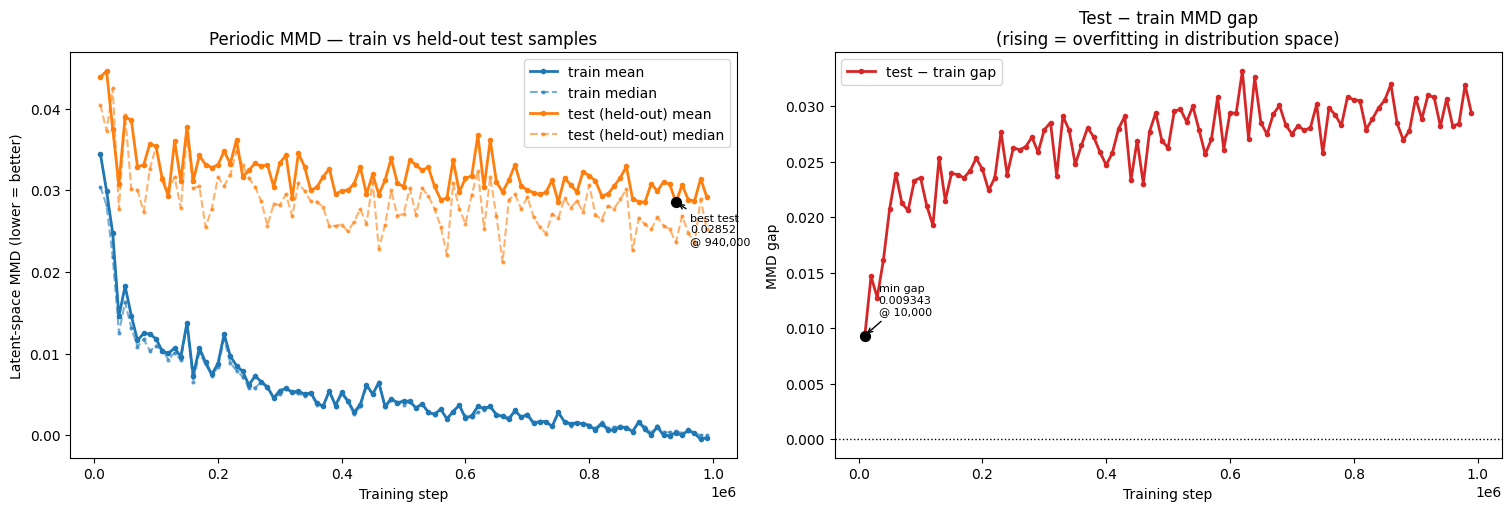

In [7]:
mmd_summary_cols = [
    'mmd_train_mean', 'mmd_train_median',
    'mmd_validation_mean', 'mmd_validation_median',
    'mmd_validation_minus_train_mean',
]
available_mmd_cols = [c for c in mmd_summary_cols if c in df.columns]

if not available_mmd_cols or not df[available_mmd_cols].notna().any().any():
    print(f'No periodic MMD summaries found in {progress_path}.')
else:
    mmd_progress = df.loc[df[available_mmd_cols].notna().any(axis=1)].copy()
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

    # ── Left panel: train vs test MMD ────────────────────────────────
    ax = axes[0]
    if 'mmd_train_mean' in mmd_progress.columns and mmd_progress['mmd_train_mean'].notna().any():
        ax.plot(mmd_progress[x_column], mmd_progress['mmd_train_mean'],
                marker='o', markersize=3, linewidth=2, color='tab:blue', label='train mean')
    if 'mmd_train_median' in mmd_progress.columns and mmd_progress['mmd_train_median'].notna().any():
        ax.plot(mmd_progress[x_column], mmd_progress['mmd_train_median'],
                marker='o', markersize=2, linewidth=1.5, linestyle='--', color='tab:blue',
                alpha=0.6, label='train median')
    if 'mmd_validation_mean' in mmd_progress.columns and mmd_progress['mmd_validation_mean'].notna().any():
        val_mean = mmd_progress['mmd_validation_mean']
        ax.plot(mmd_progress[x_column], val_mean,
                marker='o', markersize=3, linewidth=2, color='tab:orange',
                label='test (held-out) mean')
        # mark best test MMD point
        best_idx = val_mean.idxmin()
        best_x = mmd_progress.loc[best_idx, x_column]
        best_y = val_mean.loc[best_idx]
        ax.scatter([best_x], [best_y], color='black', s=50, zorder=5)
        ax.annotate(f'best test\n{best_y:.4g}\n@ {best_x:,}',
                    (best_x, best_y), xytext=(10, -30), textcoords='offset points',
                    fontsize=8, arrowprops=dict(arrowstyle='->', lw=1))
    if 'mmd_validation_median' in mmd_progress.columns and mmd_progress['mmd_validation_median'].notna().any():
        ax.plot(mmd_progress[x_column], mmd_progress['mmd_validation_median'],
                marker='o', markersize=2, linewidth=1.5, linestyle='--', color='tab:orange',
                alpha=0.6, label='test (held-out) median')

    ax.set_title('Periodic MMD — train vs held-out test samples')
    ax.set_xlabel(x_label)
    ax.set_ylabel('Latent-space MMD (lower = better)')
    ax.legend(frameon=True)

    # ── Right panel: test − train gap ────────────────────────────────
    ax = axes[1]
    if 'mmd_validation_minus_train_mean' in mmd_progress.columns and \
            mmd_progress['mmd_validation_minus_train_mean'].notna().any():
        gap = mmd_progress['mmd_validation_minus_train_mean']
        ax.plot(mmd_progress[x_column], gap, marker='o', markersize=3,
                linewidth=2, color='tab:red', label='test − train gap')
        ax.axhline(0.0, color='black', linewidth=1, linestyle=':')
        # annotate where gap is smallest (best generalization)
        best_gap_idx = gap.idxmin()
        best_gap_x = mmd_progress.loc[best_gap_idx, x_column]
        best_gap_y = gap.loc[best_gap_idx]
        ax.scatter([best_gap_x], [best_gap_y], color='black', s=50, zorder=5)
        ax.annotate(f'min gap\n{best_gap_y:.4g}\n@ {best_gap_x:,}',
                    (best_gap_x, best_gap_y), xytext=(10, 15), textcoords='offset points',
                    fontsize=8, arrowprops=dict(arrowstyle='->', lw=1))
        ax.set_title('Test − train MMD gap\n(rising = overfitting in distribution space)')
        ax.set_xlabel(x_label)
        ax.set_ylabel('MMD gap')
        ax.legend(frameon=True)
    else:
        ax.set_title('Test − train MMD gap')
        ax.text(0.5, 0.5, 'Gap column not available', ha='center', va='center',
                transform=ax.transAxes)
        ax.set_axis_off()

    plt.show()

#### Periodic MMD — training samples only

Same mean/median MMD trend as above, restricted to the train split only.

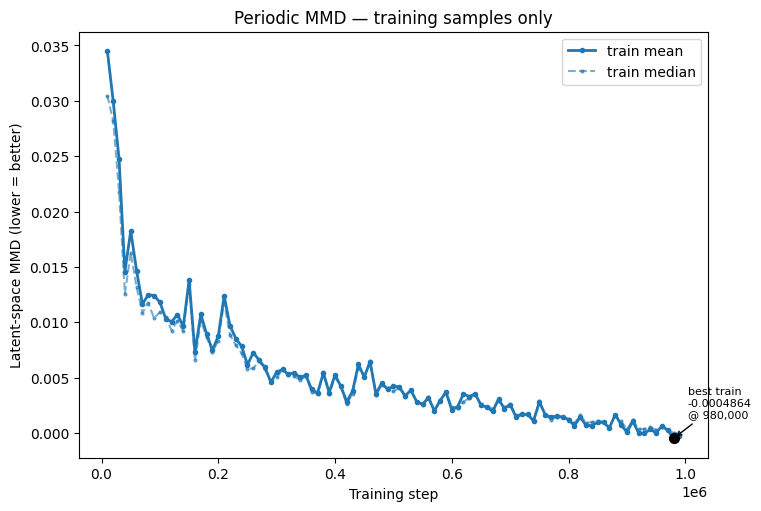

In [7]:
train_mmd_cols = ['mmd_train_mean', 'mmd_train_median']
available_train_mmd_cols = [c for c in train_mmd_cols if c in df.columns]

if not available_train_mmd_cols or not df[available_train_mmd_cols].notna().any().any():
    print(f'No periodic train-only MMD summaries found in {progress_path}.')
else:
    mmd_train_progress = df.loc[df[available_train_mmd_cols].notna().any(axis=1)].copy()
    fig, ax = plt.subplots(figsize=(7.5, 5), constrained_layout=True)

    if 'mmd_train_mean' in mmd_train_progress.columns and mmd_train_progress['mmd_train_mean'].notna().any():
        train_mean = mmd_train_progress['mmd_train_mean']
        ax.plot(mmd_train_progress[x_column], train_mean,
                marker='o', markersize=3, linewidth=2, color='tab:blue', label='train mean')
        best_idx = train_mean.idxmin()
        best_x = mmd_train_progress.loc[best_idx, x_column]
        best_y = train_mean.loc[best_idx]
        ax.scatter([best_x], [best_y], color='black', s=50, zorder=5)
        ax.annotate(f'best train\n{best_y:.4g}\n@ {best_x:,}',
                    (best_x, best_y), xytext=(10, 15), textcoords='offset points',
                    fontsize=8, arrowprops=dict(arrowstyle='->', lw=1))
    if 'mmd_train_median' in mmd_train_progress.columns and mmd_train_progress['mmd_train_median'].notna().any():
        ax.plot(mmd_train_progress[x_column], mmd_train_progress['mmd_train_median'],
                marker='o', markersize=2, linewidth=1.5, linestyle='--', color='tab:blue',
                alpha=0.6, label='train median')

    ax.set_title('Periodic MMD — training samples only')
    ax.set_xlabel(x_label)
    ax.set_ylabel('Latent-space MMD (lower = better)')
    ax.legend(frameon=True)
    plt.show()

### Per-sample MMD trajectories

Per-sample MMD curves with the median highlighted; the sample with the worst final MMD is drawn in crimson.


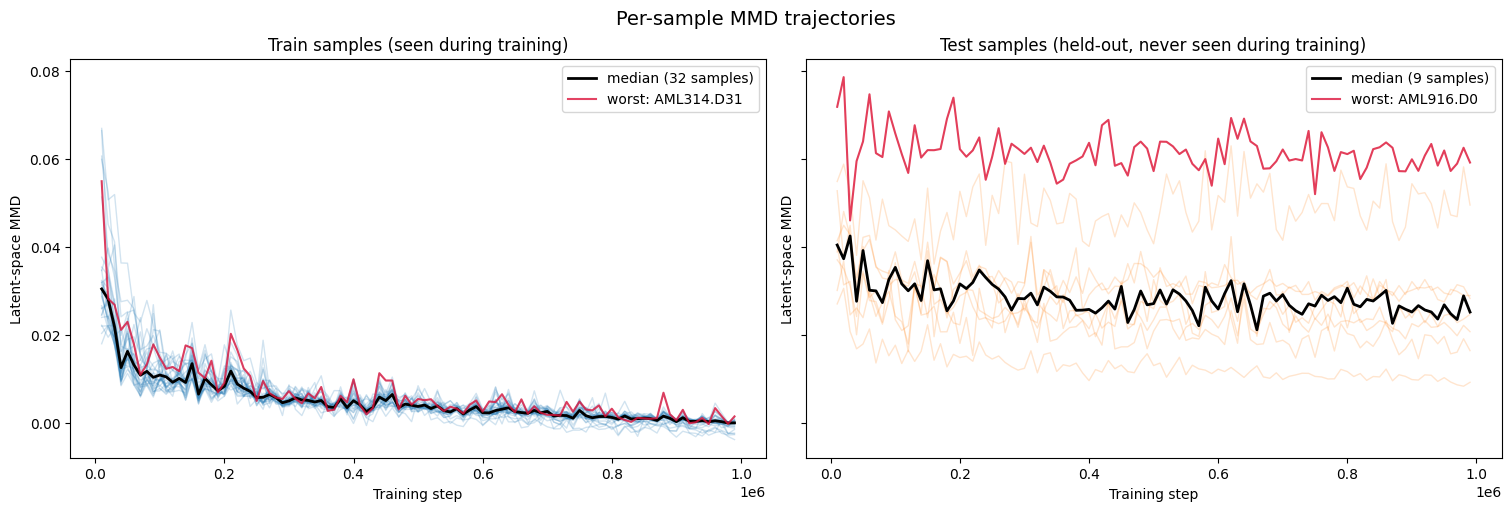

In [8]:
def plot_mmd_history_panel(ax, panel_df, *, split_label, color):
    if len(panel_df) == 0:
        ax.set_title(split_label)
        ax.text(0.5, 0.5, 'No per-sample MMD history available',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        return

    sample_ids = panel_df['sample_id'].unique()
    for sid in sample_ids:
        sdf = panel_df[panel_df['sample_id'] == sid]
        ax.plot(sdf[x_column], sdf['latent_mmd_rbf'], color=color, alpha=0.2, linewidth=1)

    median_df = panel_df.groupby(x_column, as_index=False)['latent_mmd_rbf'].median()
    ax.plot(median_df[x_column], median_df['latent_mmd_rbf'],
            color='black', linewidth=2, label=f'median ({len(sample_ids)} samples)')

    # highlight the sample with the highest final MMD
    last_step = panel_df[x_column].max()
    final_vals = panel_df[panel_df[x_column] == last_step].set_index('sample_id')['latent_mmd_rbf']
    if len(final_vals) > 0:
        worst_sid = final_vals.idxmax()
        worst_df = panel_df[panel_df['sample_id'] == worst_sid]
        ax.plot(worst_df[x_column], worst_df['latent_mmd_rbf'],
                color='crimson', linewidth=1.5, alpha=0.8, label=f'worst: {worst_sid}')

    ax.set_title(split_label)
    ax.set_xlabel(x_label)
    ax.set_ylabel('Latent-space MMD')
    ax.legend(frameon=True)


if len(mmd_history_df) == 0:
    print(f'No per-sample MMD history found at {mmd_history_path}.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True, sharey=True)
    plot_mmd_history_panel(
        axes[0],
        mmd_history_df[mmd_history_df['split'] == 'train'],
        split_label=f'Train samples (seen during training)',
        color='tab:blue',
    )
    plot_mmd_history_panel(
        axes[1],
        mmd_history_df[mmd_history_df['split'] == 'validation'],
        split_label=f'Test samples (held-out, never seen during training)',
        color='tab:orange',
    )
    fig.suptitle('Per-sample MMD trajectories', fontsize=14)
    plt.show()

## 3. Optimization diagnostics

Loss and gradient behaviour during training. These tell you whether optimization is healthy, but a low loss alone does not guarantee good generalization — cross-check against the MMD panels above.


### Core metrics — loss, gradient norm, parameter norm


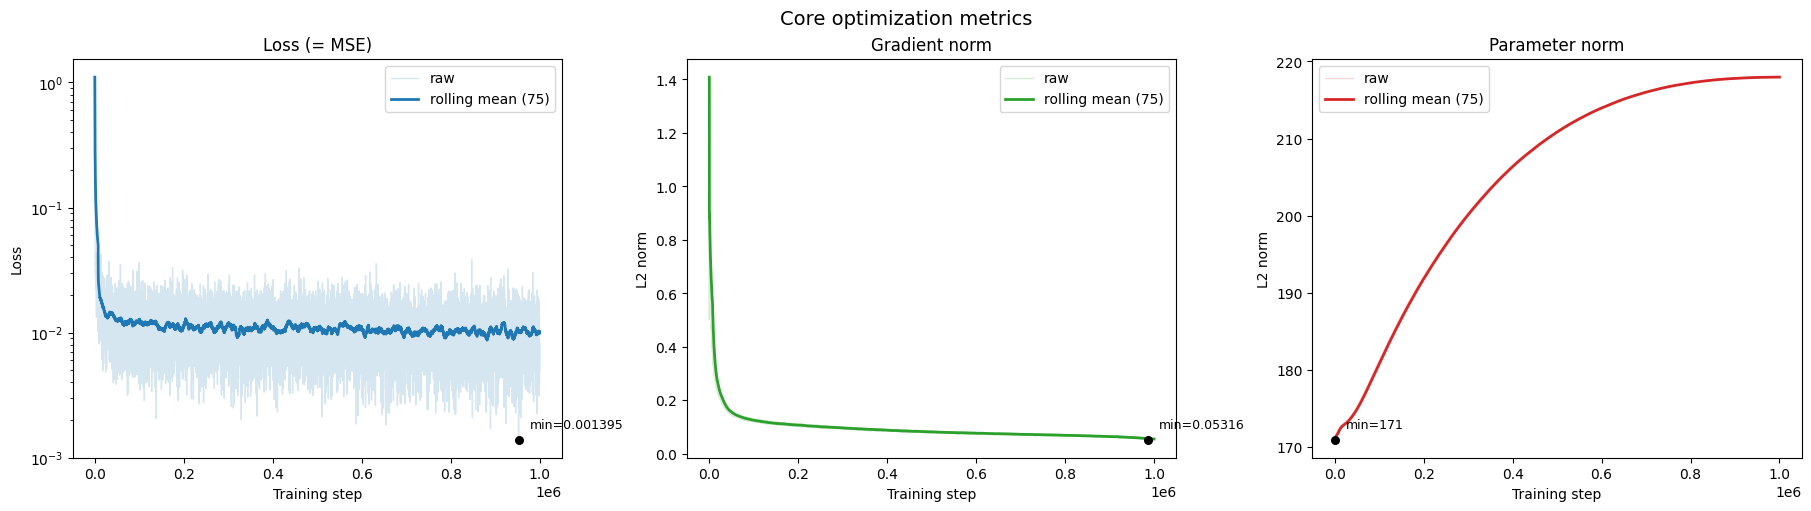

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

plot_metric(axes[0], df, 'loss', color='tab:blue', title='Loss (= MSE)', logy=True)
plot_metric(axes[1], df, 'grad_norm', color='tab:green', title='Gradient norm')
plot_metric(axes[2], df, 'param_norm', color='tab:red', title='Parameter norm')

for ax in axes:
    ax.set_ylabel('')
axes[0].set_ylabel('Loss')
axes[1].set_ylabel('L2 norm')
axes[2].set_ylabel('L2 norm')

fig.suptitle('Core optimization metrics', fontsize=14)
plt.show()

### Tail zoom — last 20% of training

Late-training behaviour, where convergence vs. drift becomes visible.


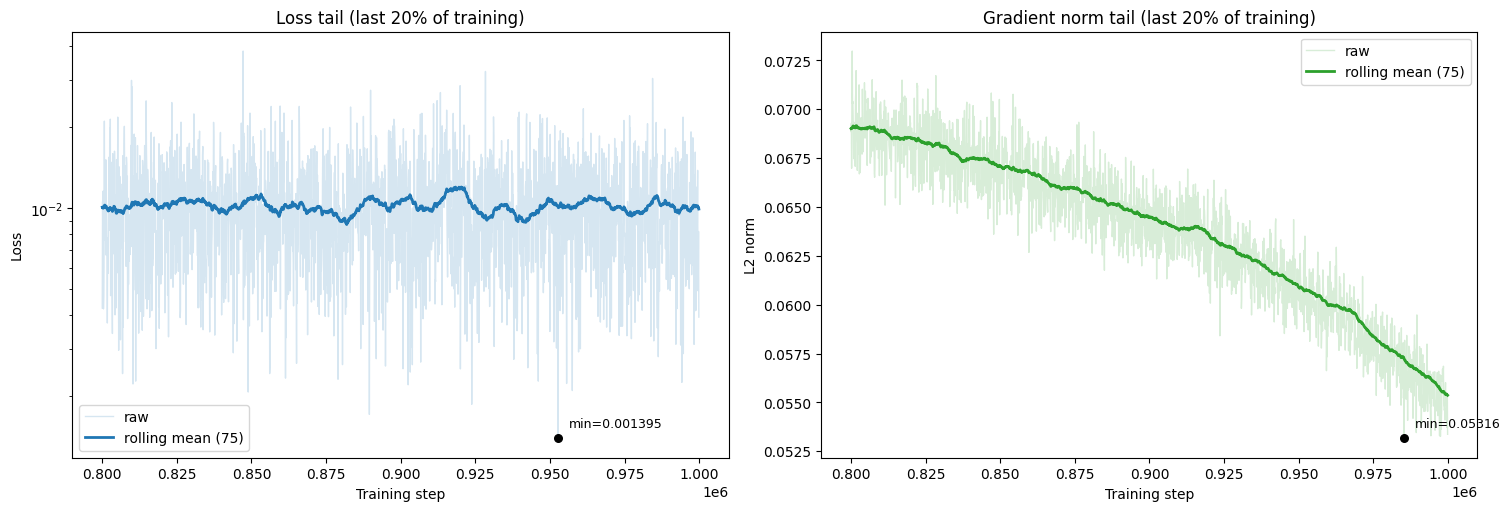

In [10]:
tail_df = df.iloc[max(0, int(len(df) * (1 - tail_fraction))):].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
plot_metric(axes[0], tail_df, 'loss', color='tab:blue',
            title=f'Loss tail (last {tail_fraction:.0%} of training)', logy=True)
plot_metric(axes[1], tail_df, 'grad_norm', color='tab:green',
            title=f'Gradient norm tail (last {tail_fraction:.0%} of training)')
axes[0].set_ylabel('Loss')
axes[1].set_ylabel('L2 norm')
plt.show()

### Loss by timestep quartile

Loss decomposed by diffusion-timestep quartile (q0 = noisiest → q3 = cleanest). Useful for spotting which timesteps dominate the loss.


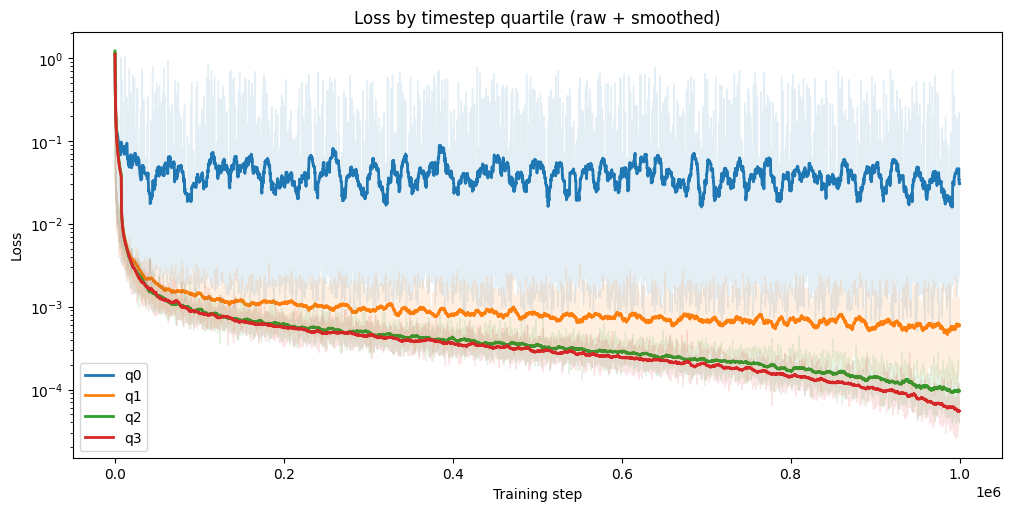

In [11]:
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for q, color in zip(range(4), colors):
    ax.plot(df[x_column], df[f'loss_q{q}'], color=color, alpha=0.12, linewidth=1)
    ax.plot(df[x_column], df[f'loss_q{q}_smooth'], color=color, linewidth=2, label=f'q{q}')

ax.set_yscale('log')
ax.set_title('Loss by timestep quartile (raw + smoothed)')
ax.set_xlabel(x_label)
ax.set_ylabel('Loss')
ax.legend(frameon=True)
plt.show()